In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = os.path.expanduser("~/gcs-data/Full_data")
os.listdir(DATA_DIR)

['2020_cleaned.csv',
 'country_continent_map.csv',
 'epicov_2020_200k.csv',
 'epicov_2021_200k.csv',
 'epicov_2023_200k.parquet',
 'epicov_2025_200k.parquet',
 'models']

In [3]:
df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))
df21 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2021_200k.csv"))
df23 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2023_200k.parquet"))
df25 = pd.read_parquet(os.path.join(DATA_DIR, "epicov_2025_200k.parquet"))
df20.shape, df21.shape, df23.shape, df25.shape

/tmp/ipykernel_30620/1650611895.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df20 = pd.read_csv(os.path.join(DATA_DIR, "epicov_2020_200k.csv"))


((200524, 18), (213997, 18), (203488, 18), (177116, 18))

In [4]:
set(df20.columns) == set(df21.columns) == set(df23.columns) == set(df25.columns)

True

In [5]:
cols = ["Accession ID", "Collection date", "Submission date"]
df = pd.concat([df20, df21, df23, df25], axis=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 795125 entries, 0 to 177115
Data columns (total 18 columns):
 #   Column                           Non-Null Count   Dtype 
---  ------                           --------------   ----- 
 0   Accession ID                     795125 non-null  object
 1   Submission date                  795125 non-null  object
 2   Virus name                       795125 non-null  object
 3   Collection date                  795125 non-null  object
 4   Location                         795125 non-null  object
 5   Host                             795125 non-null  object
 6   Additional location information  22868 non-null   object
 7   Sampling strategy                162012 non-null  object
 8   Gender                           795112 non-null  object
 9   Patient age                      795088 non-null  object
 10  Patient status                   795109 non-null  object
 11  Last vaccinated                  5690 non-null    object
 12  Passage              

In [6]:
df.rename(columns={"Accession ID": "accession_id", "Collection date": "collection_date", "Submission date": "submission_date"}, inplace=True)
# 'mixed' allows pandas to infer formats row-by-row
df["collection_date"] = pd.to_datetime(df["collection_date"], format='mixed')
df["submission_date"] = pd.to_datetime(df["submission_date"], format='mixed')
df["collection_yr"] = df["collection_date"].dt.year
df["submission_yr"] = df["submission_date"].dt.year
# Extract Day of Year (1-365) to align Jan 2020 with Jan 2022
df['collection_doy'] = df['collection_date'].dt.dayofyear
df['submission_doy'] = df['submission_date'].dt.dayofyear
df.info()   

<class 'pandas.core.frame.DataFrame'>
Index: 795125 entries, 0 to 177115
Data columns (total 22 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   accession_id                     795125 non-null  object        
 1   submission_date                  795125 non-null  datetime64[ns]
 2   Virus name                       795125 non-null  object        
 3   collection_date                  795125 non-null  datetime64[ns]
 4   Location                         795125 non-null  object        
 5   Host                             795125 non-null  object        
 6   Additional location information  22868 non-null   object        
 7   Sampling strategy                162012 non-null  object        
 8   Gender                           795112 non-null  object        
 9   Patient age                      795088 non-null  object        
 10  Patient status                   795109 non-null 

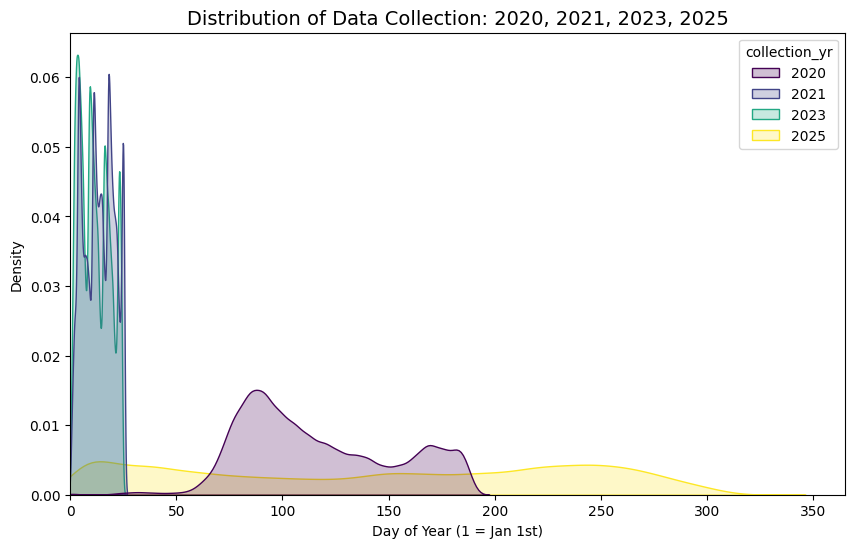

In [7]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df, x='collection_doy', hue='collection_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

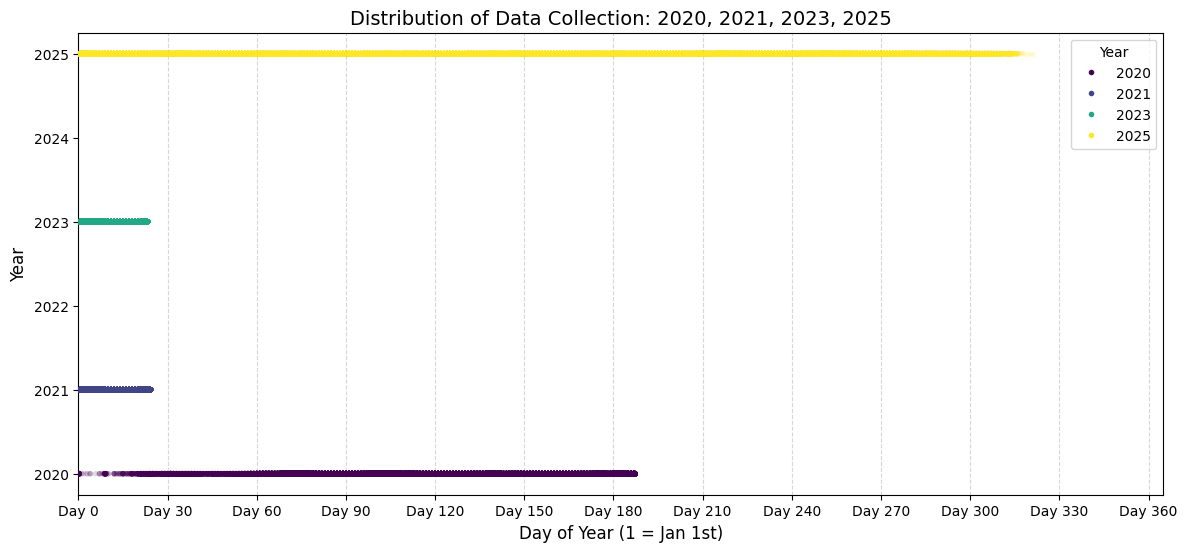

In [8]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
ax = sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df,  
    x='collection_doy', 
    y='collection_yr',           # Categorical Y-axis separates the years
    hue='collection_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=4,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Collection: 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

legend = ax.get_legend()

# Loop through the legend handles (markers) and make them opaque
if legend:
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  # 1.0 = Fully Opaque

plt.show()

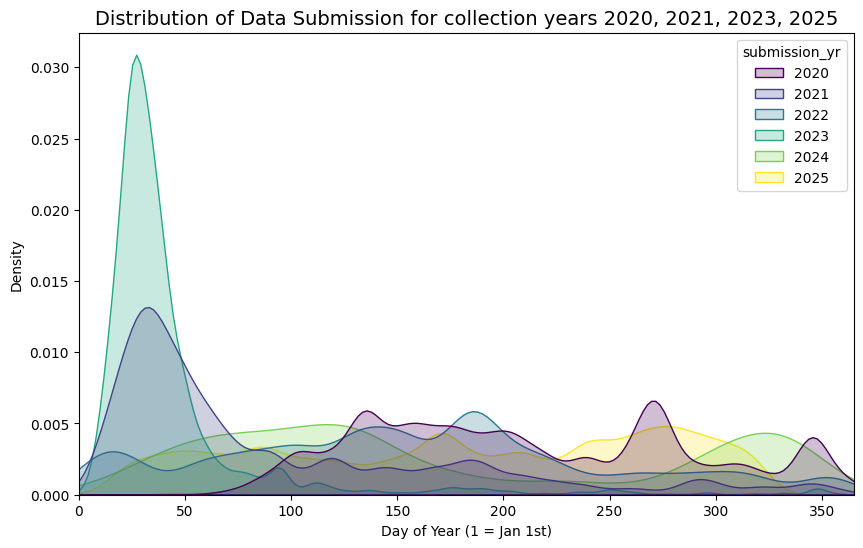

In [9]:
# 3. Plotting
plt.figure(figsize=(10, 6))

# Option A: Density Plot (The "Spike" vs "Hill")
# 'common_norm=False' allows each year to be normalized to its own volume, 
# showing the shape clearly regardless of total count differences.
sns.kdeplot(data=df, x='submission_doy', hue='submission_yr', fill=True, common_norm=False, palette='viridis')

plt.title("Distribution of Data Submission for collection years 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)")
plt.xlim(0, 365) # Lock to a full year view
plt.show()

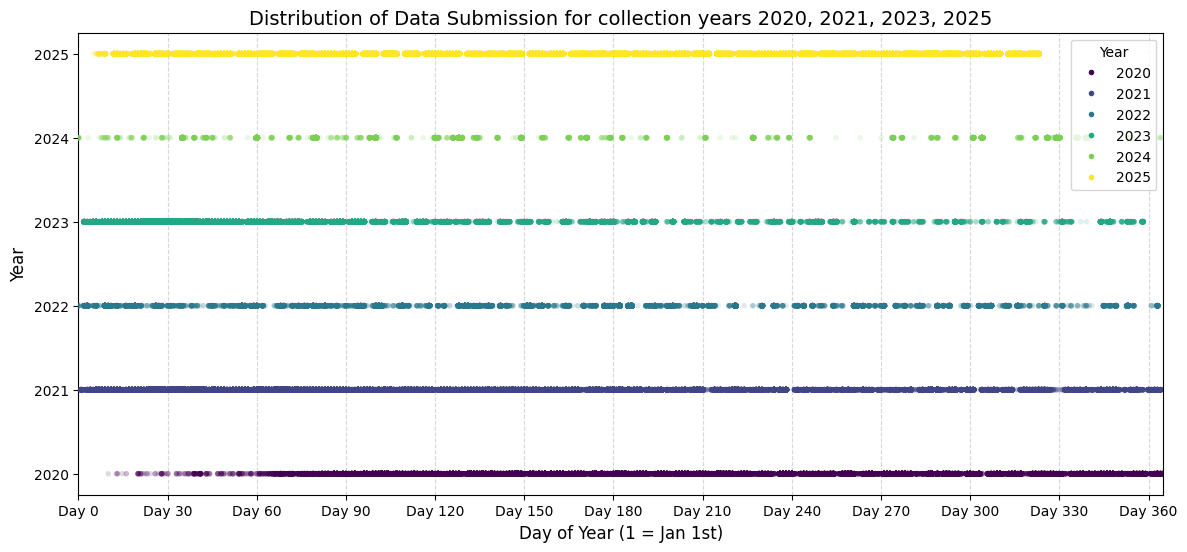

In [10]:
plt.figure(figsize=(14, 6))

# 3. Create Strip Plot
    # TIP: We use .sample(frac=0.1) to plot only 10% of data for speed/clarity. 
    # If you want all data, remove .sample() but lower 'alpha' and 'size'.
ax = sns.stripplot(
    # data=df.sample(frac=0.1, random_state=42),
    data=df,  
    x='submission_doy', 
    y='submission_yr',           # Categorical Y-axis separates the years
    hue='submission_yr',         # Colors them differently
    jitter=0.25,        # Adds random vertical noise so dots don't overlap perfectly
    size=4,             # Keep dots small
    alpha=0.15,          # High transparency to show density (darker = more data)
    palette='viridis'
)

# plt.title("Timeline of Data Collection by Year (Strip Plot)", fontsize=14)
plt.title("Distribution of Data Submission for collection years 2020, 2021, 2023, 2025", fontsize=14)
plt.xlabel("Day of Year (1 = Jan 1st)", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.xlim(0, 365)  # Lock axis to full year
plt.grid(True, axis='x', linestyle='--', alpha=0.5)

plt.xticks(ticks=np.arange(0, 366, 30), labels=[f"Day {i}" for i in np.arange(0, 366, 30)])
plt.legend(title='Year', loc='upper right')

legend = ax.get_legend()

# Loop through the legend handles (markers) and make them opaque
if legend:
    for handle in legend.legend_handles:
        handle.set_alpha(1.0)  # 1.0 = Fully Opaque

plt.show()

In [11]:
from countryinfo import CountryInfo

def get_language_codes(country_name):
    try:
        # CountryInfo is smart enough to handle many common aliases
        # e.g., "USA", "UK", "Democratic Republic of Congo"
        country = CountryInfo(country_name)
        
        # .languages() returns a list of ISO 639-1 (2-letter) codes
        codes = country.languages()
        
        if codes:
            return codes
        else:
            return "No language data found."
            
    except KeyError:
        return "Country name not recognized. Try a different variation."

# --- Examples ---
print(f"USA: {get_language_codes('USA')}")
print(f"Congo (Republic): {get_language_codes('Republic of Congo')}")
print(f"Congo (DRC): {get_language_codes('Democratic Republic of the Congo')}")
print(f"Japan: {get_language_codes('Japan')}")

USA: ['en']
Congo (Republic): Country name not recognized. Try a different variation.
Congo (DRC): ['fr', 'ln', 'kg', 'sw', 'lu']
Japan: ['ja']


In [12]:
# Vectorized split and strip (much faster than iterrows)
parts = df["Location"].astype(str).str.split("/", n=3, expand=True)
parts = parts.rename(columns={0: "continent", 1: "country", 2: "state", 3: "city"})
# strip whitespace and replace empty strings with NaN
for c in parts.columns:
    parts[c] = parts[c].where(parts[c].notna(), np.nan).astype(object)
    parts[c] = parts[c].str.strip().replace({"": np.nan})

# Assign new location columns directly (avoid relying on `cols` variable)
df[["continent", "country", "state", "city"]] = parts[["continent", "country", "state", "city"]]
df.drop(columns=["Location"], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 795125 entries, 0 to 177115
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   accession_id                     795125 non-null  object        
 1   submission_date                  795125 non-null  datetime64[ns]
 2   Virus name                       795125 non-null  object        
 3   collection_date                  795125 non-null  datetime64[ns]
 4   Host                             795125 non-null  object        
 5   Additional location information  22868 non-null   object        
 6   Sampling strategy                162012 non-null  object        
 7   Gender                           795112 non-null  object        
 8   Patient age                      795088 non-null  object        
 9   Patient status                   795109 non-null  object        
 10  Last vaccinated                  5690 non-null   

In [13]:
df["Patient status"].nunique(), df["Patient status"].value_counts()

(258,
 Patient status
 unknown                    744496
 Live                        15783
 Hospitalized                 8871
 Symptomatic                  4849
 Released                     4270
                             ...  
 Recovered (no symptoms)         1
 16                              1
 95                              1
 35                              1
 57                              1
 Name: count, Length: 258, dtype: int64)

In [16]:
unknown_vals = df[df["Patient status"].astype(str).str.lower().str.startswith("u")]["Patient status"].unique().tolist()
mask = df["Patient status"].isin(unknown_vals)
df.loc[mask, "Patient status"] = "unknown"
df["Patient status"].fillna("unknown", inplace=True)
df["Patient status"].nunique(), df["Patient status"].value_counts()

/tmp/ipykernel_30620/2691384461.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Patient status"].fillna("unknown", inplace=True)


(251,
 Patient status
 unknown         745345
 Live             15783
 Hospitalized      8871
 Symptomatic       4849
 Released          4270
                  ...  
 64                   1
 0                    1
 83                   1
 78                   1
 3                    1
 Name: count, Length: 251, dtype: int64)

In [24]:
def is_numeric_string(s):
    boolean = True
    for c in s:
        if c == '.':
            continue
        boolean *= c.isdigit()
    return {1:True, 0:False}.get(boolean, False)
num_vals = df[df["Patient status"].astype(str).apply(is_numeric_string)]["Patient status"].unique().tolist()
mask = df["Patient status"].isin(num_vals)
df.loc[mask, "Patient status"] = "unknown"
df["Patient status"].nunique(), df["Patient status"].value_counts()

(215,
 Patient status
 unknown                    745403
 Live                        15783
 Hospitalized                 8871
 Symptomatic                  4849
 Released                     4270
                             ...  
 Missing                         1
 Screen                          1
 Recovered (no symptoms)         1
 ALive                           1
 Severe; Deceased                1
 Name: count, Length: 215, dtype: int64)

In [25]:
sorted(set([str(x).lower() for x in df["Patient status"].values]))

['active',
 'active, non-sentinel-surveillance (hospital)',
 'acute bronchitis',
 'acute upper respiratory infection, unspecified',
 'alive',
 'alive, no death no hospitalization',
 'ambulatory',
 'asymptomatic',
 'asymptomatic, identified as positive during preoperation investigation',
 'asymptomatic/mild',
 'asymptomatic/released',
 'asymptomatic; deceased',
 'asymptomatic; recovered',
 'asymtomatic',
 'aymptomatic',
 'bronchitis',
 'cas contact',
 'cas suspect',
 'casualty',
 'chronic dialysis',
 'clinic',
 'community screening',
 'community surveillance',
 'confirmed sad',
 'confirmed sad-sad',
 'confirmed scte',
 'contact',
 'contact surveillance',
 'contact with and exposure to other communicable diseases',
 'contact-sad',
 'cure',
 'cured',
 'dama',
 'dead',
 'dead, hospitalized',
 'death',
 'decease',
 'deceased',
 'deceased (bid)',
 'discharged',
 'discharged after recovery',
 'discharged alive',
 'domestic infection',
 'ehpad',
 'ehpad_ira',
 'epidemiology study',
 'etude',
 

In [ ]:
for i,row in df[df["Patient status"].astype(str).str.strip().str.isnumeric()][["Patient status","Gender", "Patient age"]].iterrows():
    if row["Patient status"].strip() != row["Patient age"].strip():
        print(f"Row {i}: Patient status '{row['Patient status']}' does not matche Patient age '{row['Patient age']}'")

In [ ]:
mask = df[df["Patient status"].astype(str).str.strip().str.isnumeric()]
df.loc[mask.index, "Patient status"] = "unknown"

In [ ]:
mask = df[df["Patient status"].astype(str).str.lower().str.startswith("u")]
df.loc[mask.index, "Patient status"] = "unknown"

In [26]:
years = sorted(df["collection_yr"].dropna().unique())

for year in years:
    total = df[df["collection_yr"] == year].shape[0]
    unknown_pat_status = df[(df["collection_yr"] == year) & (df["Patient status"] == "unknown")].shape[0]
    print(f"Year {year}: {unknown_pat_status} out of {total} samples have 'unknown' Patient status ({(1 - (unknown_pat_status/total))*100}%)")

Year 2020: 183410 out of 200524 samples have 'unknown' Patient status (8.534639245177633%)
Year 2021: 203851 out of 213997 samples have 'unknown' Patient status (4.741187960578886%)
Year 2023: 192411 out of 203488 samples have 'unknown' Patient status (5.443564239660326%)
Year 2025: 165731 out of 177116 samples have 'unknown' Patient status (6.427990695363494%)


In [27]:
df["Patient status"].nunique(), df["Patient status"].value_counts()

(215,
 Patient status
 unknown                    745403
 Live                        15783
 Hospitalized                 8871
 Symptomatic                  4849
 Released                     4270
                             ...  
 Missing                         1
 Screen                          1
 Recovered (no symptoms)         1
 ALive                           1
 Severe; Deceased                1
 Name: count, Length: 215, dtype: int64)